In [38]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import rasterio as rio
from rasterio.plot import reshape_as_image, reshape_as_raster
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from matplotlib.colors import ListedColormap
from kneed import KneeLocator
import pandas as pd
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import matplotlib.colors as colors

In [39]:
"""
def apply_mask(image_path, mask_path):
    # Preparing image
    raster_img = rio.open(image_path)                  # get image with image path
    arr_img = reshape_as_image(raster_img.read())      # turn it into an array
    mask_norm = np.all((arr_img >= 0) & (arr_img <= 1), axis=2)
    mask_zero = np.all(arr_img == 0, axis=2)
    arr_img[(~mask_norm) | (mask_zero)] = np.nan
    image = reshape_as_raster(arr_img)
    l, m, n = image.shape                              # check the size of the image 
    #print("Size of the image is "+str(l)+"x"+str(m)+"x"+str(n))
    X = image.reshape(l, -1).T                         # image reshaped as (mxn), l
    scaler = StandardScaler()                                     
    X_scaled = scaler.fit_transform(X)                 # scale the data

    # Preparing mask
    with rio.open(mask_path) as src:
        image = src.read(1)                            # Lire la première bande
    mask_soil = (image > 0).astype(np.uint8)           # 0 is mask, 1 is image
    
    unique, counts = np.unique(mask_soil, return_counts=True)
    print(dict(zip(unique, counts)))
    
    mask_soil_elargi = mask_soil[:,:,np.newaxis]       # so the mask covers all of the spectral bands
    vec_new = np.repeat(mask_soil_elargi,  X_scaled.shape[1], axis=2)  # shape = (m, n, l)
    X_scaled_soil = X_scaled.reshape(m,n,l)*vec_new    # reshape the image to apply the mask correctly
    RED = X_scaled_soil[:, :, 2]
    GREEN = X_scaled_soil[:, :, 1]
    BLUE = X_scaled_soil[:, :, 0]
    rgb = np.stack([RED, GREEN, BLUE], axis=-1)
    print(rgb.shape, len(rgb), rgb.shape[0]*rgb.shape[1]*rgb.shape[2])
    print("count is", abs(np.count_nonzero(rgb) - rgb.shape[0]*rgb.shape[1]*rgb.shape[2]))
    
    min_val = np.nanmin(rgb, axis=(0,1))               # normalize band by band
    max_val = np.nanmax(rgb, axis=(0,1))               
    scale = max_val - min_val                          # Avoid to divide by 0
    scale[scale == 0] = 1                              # change 0 by 1 to avoid warnings
    rgb_norm = (rgb - min_val) / scale                 # normalize the rgb image
    
    plt.imshow(rgb_norm)
    plt.axis('off')
    plt.show()
    return rgb_norm
"""

'\ndef apply_mask(image_path, mask_path):\n    # Preparing image\n    raster_img = rio.open(image_path)                  # get image with image path\n    arr_img = reshape_as_image(raster_img.read())      # turn it into an array\n    mask_norm = np.all((arr_img >= 0) & (arr_img <= 1), axis=2)\n    mask_zero = np.all(arr_img == 0, axis=2)\n    arr_img[(~mask_norm) | (mask_zero)] = np.nan\n    image = reshape_as_raster(arr_img)\n    l, m, n = image.shape                              # check the size of the image \n    #print("Size of the image is "+str(l)+"x"+str(m)+"x"+str(n))\n    X = image.reshape(l, -1).T                         # image reshaped as (mxn), l\n    scaler = StandardScaler()                                     \n    X_scaled = scaler.fit_transform(X)                 # scale the data\n\n    # Preparing mask\n    with rio.open(mask_path) as src:\n        image = src.read(1)                            # Lire la première bande\n    mask_soil = (image > 0).astype(np.uint8)   

In [40]:
def apply_mask(image_path, mask_path):
    # --- Image ---
    raster_img = rio.open(image_path)
    arr_img = reshape_as_image(raster_img.read())  # (m, n, l)

    # On ne met NaN que pour les pixels hors [0,1] (les zéros restent)
    mask_norm = np.all((arr_img >= 0) & (arr_img <= 1), axis=2)
    arr_img[~mask_norm] = np.nan

    image = reshape_as_raster(arr_img)
    l, m, n = image.shape

    X = image.reshape(l, -1).T
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # --- Masque ---
    with rio.open(mask_path) as src:
        mask_band = src.read(1)                 # (m, n)
    mask_soil = (mask_band > 0).astype(np.uint8)  # 1 = zone affichée, 0 = fond

    mask_soil_elargi = mask_soil[:, :, np.newaxis]          # (m, n, 1)
    vec_new = np.repeat(mask_soil_elargi, X_scaled.shape[1], axis=2)  # (m, n, l)

    X_scaled_soil = X_scaled.reshape(m, n, l) * vec_new

    # --- RGB ---
    RED   = X_scaled_soil[:, :, 2]
    GREEN = X_scaled_soil[:, :, 1]
    BLUE  = X_scaled_soil[:, :, 0]
    rgb = np.stack([RED, GREEN, BLUE], axis=-1)   # (m, n, 3)

    # --- Normalisation canal par canal ---
    min_val = np.nanmin(rgb, axis=(0, 1))
    max_val = np.nanmax(rgb, axis=(0, 1))
    scale = max_val - min_val
    scale[scale == 0] = 1
    rgb_norm = (rgb - min_val) / scale

    # --- FORCER le fond à noir ---
    # mask_soil == 0 -> fond, on les met à (0,0,0)
    fond = (mask_soil == 0)           # (m, n) bool
    rgb_norm[fond] = 0.0              # broadcasting sur la 3ème dimension

    plt.imshow(rgb_norm)
    plt.axis('off')
    plt.show()

    return rgb_norm, fond

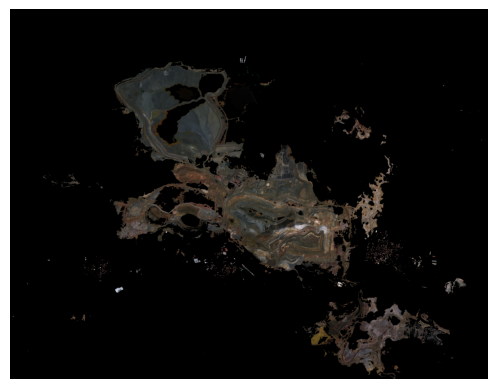

In [41]:
soil_only, fond_soil = apply_mask(r'./SENTINEL2B_20240410-112055-466_L2A_T29SQB_C_V3-1_FRE_extrait_stack_gain_VNIR10.img',
                       r"./mask_total_soil_VSWIR_10m.img")

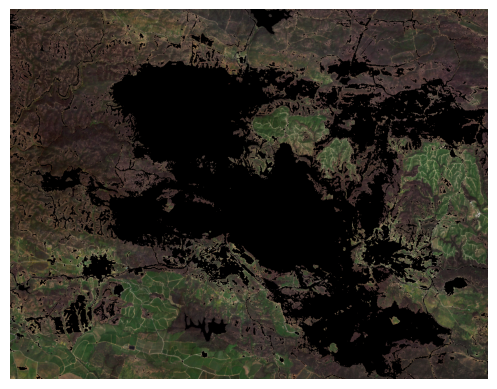

In [42]:
vegetation_only, fond_vegetation = apply_mask(r'./SENTINEL2B_20240410-112055-466_L2A_T29SQB_C_V3-1_FRE_extrait_stack_gain_VNIR10.img',
                             r"./SENTINEL2B_20240410-112055-466_L2A_T29SQB_C_V3-1_mask_veg.img")

In [43]:
'''def compute_ndvi(nir, red):
    nir = nir.astype(float)
    red = red.astype(float)
    
    ndvi = (nir - red) / (nir + red)
    
    # Évite les divisions par zéro
    ndvi = np.where((nir + red) == 0, 0, ndvi)
    
    return ndvi, nir

# Exemple d'utilisation :
ndvi, nir = compute_ndvi(image[-1,:,:], image[2,:,:])'''

"def compute_ndvi(nir, red):\n    nir = nir.astype(float)\n    red = red.astype(float)\n\n    ndvi = (nir - red) / (nir + red)\n\n    # Évite les divisions par zéro\n    ndvi = np.where((nir + red) == 0, 0, ndvi)\n\n    return ndvi, nir\n\n# Exemple d'utilisation :\nndvi, nir = compute_ndvi(image[-1,:,:], image[2,:,:])"

In [44]:
'''
# Seuil NDVI (à ajuster selon ton cas)
threshold_ndvi = 0.3
#threshold_nir = 2800

# Mask binaire : 1 = végétation, 0 = non-végétation
veg_mask = (ndvi > threshold_ndvi) #& (nir > threshold_nir)

# On étend le mask en 3D pour l’appliquer aux bandes
veg_mask_3d = veg_mask[None, :, :]  # shape -> (H, W, 1)

# Array final : mêmes dimensions, pixels non végétation = 0
veg_only = np.where(veg_mask_3d, image, 0)

# Indices Sentinel-2 : (si image = [B1, B2, B3, B4, B5, ...])
RED   = veg_only[2, :, :]
GREEN = veg_only[1, :, :]
BLUE  = veg_only[0, :, :]

rgb = np.stack([RED, GREEN, BLUE], axis=-1)

# Normalisation bande par bande
min_val = np.nanmin(rgb, axis=(0,1))
max_val = np.nanmax(rgb, axis=(0,1))

# Évite division par zéro
scale = max_val - min_val
scale[scale == 0] = 1  # remplacer 0 par 1 pour éviter le warning

rgb_norm = (rgb - min_val) / scale

plt.imshow(rgb_norm)
plt.axis('off')
plt.show()
'''

"\n# Seuil NDVI (à ajuster selon ton cas)\nthreshold_ndvi = 0.3\n#threshold_nir = 2800\n\n# Mask binaire : 1 = végétation, 0 = non-végétation\nveg_mask = (ndvi > threshold_ndvi) #& (nir > threshold_nir)\n\n# On étend le mask en 3D pour l’appliquer aux bandes\nveg_mask_3d = veg_mask[None, :, :]  # shape -> (H, W, 1)\n\n# Array final : mêmes dimensions, pixels non végétation = 0\nveg_only = np.where(veg_mask_3d, image, 0)\n\n# Indices Sentinel-2 : (si image = [B1, B2, B3, B4, B5, ...])\nRED   = veg_only[2, :, :]\nGREEN = veg_only[1, :, :]\nBLUE  = veg_only[0, :, :]\n\nrgb = np.stack([RED, GREEN, BLUE], axis=-1)\n\n# Normalisation bande par bande\nmin_val = np.nanmin(rgb, axis=(0,1))\nmax_val = np.nanmax(rgb, axis=(0,1))\n\n# Évite division par zéro\nscale = max_val - min_val\nscale[scale == 0] = 1  # remplacer 0 par 1 pour éviter le warning\n\nrgb_norm = (rgb - min_val) / scale\n\nplt.imshow(rgb_norm)\nplt.axis('off')\nplt.show()\n"

In [45]:
'''
# Pixels restants (non-végétation)
non_veg_mask = ~veg_mask

# Extraire bandes nécessaires
green = image[1, :, :]  # B3
nir   = image[-1, :, :]  # B8

# Calcul NDWI
ndwi = (green - nir) / (green + nir)
ndwi = np.where((green + nir) == 0, 0, ndwi)

# Détection de l'eau
threshold_ndwi = 0  # à ajuster
water_mask = (ndwi > threshold_ndwi) & non_veg_mask

# Étendre le masque sur les bandes
water_mask_3d = water_mask[None, :, :]

# Pixels eau gardés, autres = 0
water_only = np.where(water_mask_3d, image, 0)

RED   = water_only[2, :, :] #+ veg_only[2, :, :]
GREEN = water_only[1, :, :] #+ veg_only[1, :, :]
BLUE  = water_only[0, :, :] #+ veg_only[0, :, :]

rgb_water = np.stack([RED, GREEN, BLUE], axis=-1)

# Normalisation bande par bande
min_val = np.nanmin(rgb_water, axis=(0,1))
max_val = np.nanmax(rgb_water, axis=(0,1))
scale = max_val - min_val
scale[scale == 0] = 1
rgb_norm = (rgb_water - min_val) / scale

plt.imshow(rgb_norm)
plt.axis('off')
plt.show()
'''

"\n# Pixels restants (non-végétation)\nnon_veg_mask = ~veg_mask\n\n# Extraire bandes nécessaires\ngreen = image[1, :, :]  # B3\nnir   = image[-1, :, :]  # B8\n\n# Calcul NDWI\nndwi = (green - nir) / (green + nir)\nndwi = np.where((green + nir) == 0, 0, ndwi)\n\n# Détection de l'eau\nthreshold_ndwi = 0  # à ajuster\nwater_mask = (ndwi > threshold_ndwi) & non_veg_mask\n\n# Étendre le masque sur les bandes\nwater_mask_3d = water_mask[None, :, :]\n\n# Pixels eau gardés, autres = 0\nwater_only = np.where(water_mask_3d, image, 0)\n\nRED   = water_only[2, :, :] #+ veg_only[2, :, :]\nGREEN = water_only[1, :, :] #+ veg_only[1, :, :]\nBLUE  = water_only[0, :, :] #+ veg_only[0, :, :]\n\nrgb_water = np.stack([RED, GREEN, BLUE], axis=-1)\n\n# Normalisation bande par bande\nmin_val = np.nanmin(rgb_water, axis=(0,1))\nmax_val = np.nanmax(rgb_water, axis=(0,1))\nscale = max_val - min_val\nscale[scale == 0] = 1\nrgb_norm = (rgb_water - min_val) / scale\n\nplt.imshow(rgb_norm)\nplt.axis('off')\nplt.show

In [46]:
'''non_water_mask = ~water_mask
soil_mask = non_veg_mask & non_water_mask
soil_mask_3d = soil_mask[None, :, :]
soil_only = np.where(soil_mask_3d, image, 0)

RED   = soil_only[2, :, :] #+ veg_only[2, :, :]
GREEN = soil_only[1, :, :] #+ veg_only[1, :, :]
BLUE  = soil_only[0, :, :] #+ veg_only[0, :, :]

rgb_soil = np.stack([RED, GREEN, BLUE], axis=-1)

# Normalisation bande par bande
min_val = np.nanmin(rgb_soil, axis=(0,1))
max_val = np.nanmax(rgb_soil, axis=(0,1))
scale = max_val - min_val
scale[scale == 0] = 1
rgb_norm = (rgb_soil - min_val) / scale

plt.imshow(rgb_norm)
plt.axis('off')
plt.show()
'''

"non_water_mask = ~water_mask\nsoil_mask = non_veg_mask & non_water_mask\nsoil_mask_3d = soil_mask[None, :, :]\nsoil_only = np.where(soil_mask_3d, image, 0)\n\nRED   = soil_only[2, :, :] #+ veg_only[2, :, :]\nGREEN = soil_only[1, :, :] #+ veg_only[1, :, :]\nBLUE  = soil_only[0, :, :] #+ veg_only[0, :, :]\n\nrgb_soil = np.stack([RED, GREEN, BLUE], axis=-1)\n\n# Normalisation bande par bande\nmin_val = np.nanmin(rgb_soil, axis=(0,1))\nmax_val = np.nanmax(rgb_soil, axis=(0,1))\nscale = max_val - min_val\nscale[scale == 0] = 1\nrgb_norm = (rgb_soil - min_val) / scale\n\nplt.imshow(rgb_norm)\nplt.axis('off')\nplt.show()\n"

Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done


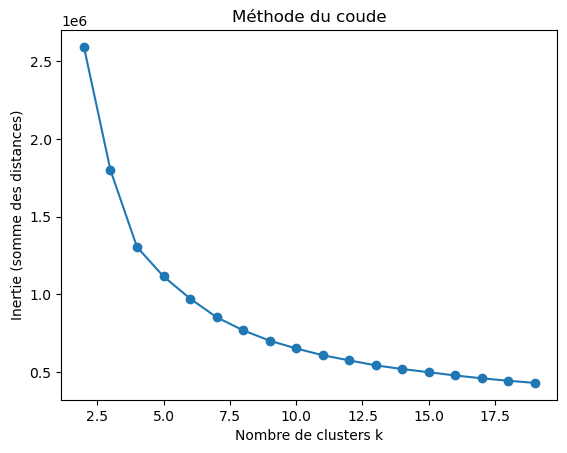

k optimal trouvé = 6


In [47]:
# Flatten mask
"""
veg_idx = veg_mask.flatten()

pixels = image.reshape(l, -1).T      # → (H*W, C)
veg_pixels = pixels[veg_idx]         # → (N_veg, C)
"""

image_path = r'./SENTINEL2B_20240410-112055-466_L2A_T29SQB_C_V3-1_FRE_extrait_stack_gain_VNIR10.img'
raster_img = rio.open(image_path)
arr_img = reshape_as_image(raster_img.read())  # (m, n, l)
image = reshape_as_raster(arr_img)
l, m, n = image.shape

veg_mask_2d = (vegetation_only[:, :, 0] != 0)  # prendre la première bande uniquement
veg_mask_1d = veg_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = arr_img.reshape(-1, l)               # (m*n, l)
veg_pixels = pixels[veg_mask_1d]             # (N_veg, l) → uniquement végétation

scaler = StandardScaler()
X_scaled = scaler.fit_transform(veg_pixels)

inertias = []
    #sil_scores = []

K_range = range(2, 20, 1)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=3, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    print("Done")

plt.plot(K_range, inertias, marker='o')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie (somme des distances)')
plt.title('Méthode du coude')
plt.show()

knee = KneeLocator(K_range, inertias, curve='convex', direction='decreasing')
optimal_k = knee.knee

print(f"k optimal trouvé = {optimal_k}")


X_scaled shape : (668215, 8)
labels shape   : (668215,)
labels uniques : {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5)}
Silhouette (échantillon) pour k = 6 : 0.316
Calinski-Harabasz pour k = 6 : 599794.62
(668215,)
(668215, 8)
            Bande_1   Bande_2   Bande_3   Bande_4   Bande_5   Bande_6  \
Cluster_1  0.043460  0.069880  0.057731  0.107275  0.242113  0.277239   
Cluster_2  0.044699  0.063575  0.059995  0.092859  0.178087  0.199501   
Cluster_3  0.054397  0.077637  0.078775  0.113608  0.198964  0.220534   
Cluster_4  0.043696  0.076341  0.055511  0.117817  0.304226  0.356192   
Cluster_5  0.036739  0.052941  0.047628  0.076966  0.157723  0.178596   
Cluster_6  0.065026  0.098027  0.094966  0.141825  0.268036  0.301948   

            Bande_7   Bande_8  
Cluster_1  0.286078  0.301313  
Cluster_2  0.204214  0.216956  
Cluster_3  0.225970  0.238480  
Cluster_4  0.370913  0.385540  
Cluster_5  0.183013  0.194610  
Cluster_6  0.310166  0.325448  


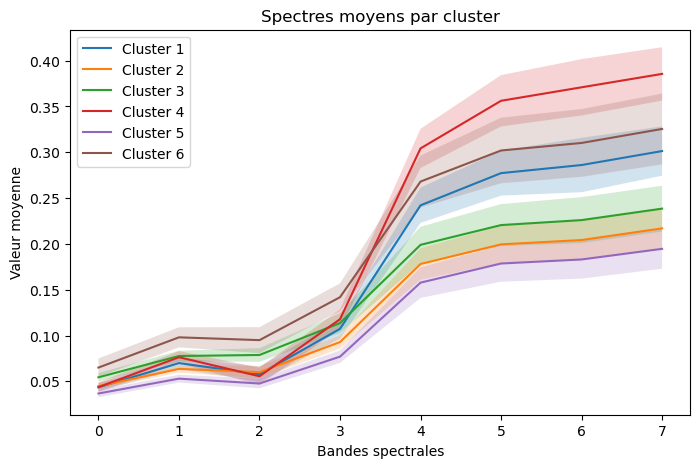

In [48]:
optimal_k = 6
# --- 6) K-Means final avec k optimal ---
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
labels = kmeans_final.fit_predict(X_scaled)

print("X_scaled shape :", X_scaled.shape)
print("labels shape   :", labels.shape)
print("labels uniques :", set(labels))

max_samples = 10000  # à ajuster si tu veux plus ou moins de précision
n_samples = X_scaled.shape[0]

if n_samples > max_samples:
    idx = np.random.choice(n_samples, max_samples, replace=False)
    X_sampled = X_scaled[idx]
    labels_sampled = labels[idx]
else:
    X_sampled = X_scaled
    labels_sampled = labels

sil_score = silhouette_score(X_sampled, labels_sampled)
ch_score  = calinski_harabasz_score(X_scaled, labels)

print(f"Silhouette (échantillon) pour k = {optimal_k} : {sil_score:.3f}")
print(f"Calinski-Harabasz pour k = {optimal_k} : {ch_score:.2f}")


print(labels.shape)
print(veg_pixels.shape)

# Calcul des moyennes par cluster
mean_spectra = np.zeros((optimal_k, veg_pixels.shape[1]))
std_spectra = np.zeros((optimal_k, veg_pixels.shape[1]))

for k in range(optimal_k):
    cluster_pixels = veg_pixels[labels == k]
    mean_spectra[k] = cluster_pixels.mean(axis=0)
    std_spectra[k]  = cluster_pixels.std(axis=0)

# Option : afficher sous forme de tableau avec pandas
df_mean_spectra = pd.DataFrame(
    mean_spectra, 
    columns=[f'Bande_{i+1}' for i in range(veg_pixels.shape[1])]
)
df_mean_spectra.index = [f'Cluster_{i+1}' for i in range(optimal_k)]

print(df_mean_spectra)

plt.figure(figsize=(8,5))
bands = np.arange(l)

for k in range(optimal_k):
    plt.plot(mean_spectra[k], label=f'Cluster {k+1}')
    plt.fill_between(
        bands,
        mean_spectra[k] - std_spectra[k],
        mean_spectra[k] + std_spectra[k],
        alpha=0.2
    )
plt.xlabel('Bandes spectrales')
plt.ylabel('Valeur moyenne')
plt.title('Spectres moyens par cluster')
plt.legend()
plt.show()

6 classes pour la végétation selon le critère du coude

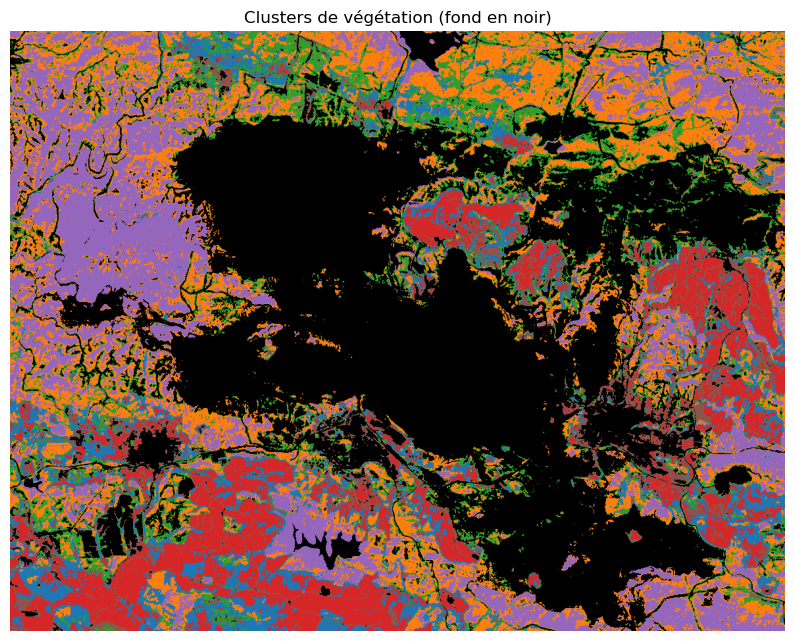

In [49]:
# --- 7) Construction de la carte finale ---
cluster_map = np.zeros((m, n), dtype=int)
cluster_map[veg_mask_2d] = labels + 1  # 0 = fond, clusters à partir de 1

# --- 8) Création de la colormap ---
cmap_colors = ["black"] + list(plt.cm.tab10.colors[:optimal_k])
cmap = colors.ListedColormap(cmap_colors)

# --- 9) Affichage ---
plt.figure(figsize=(10,10))
plt.imshow(cluster_map, cmap=cmap)
plt.axis('off')
plt.title("Clusters de végétation (fond en noir)")
plt.show()

Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done


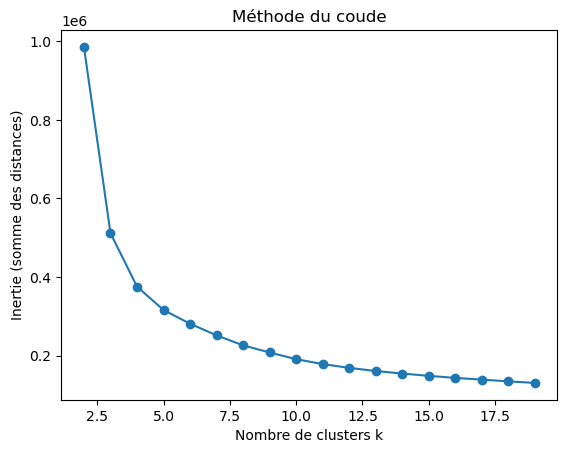

k optimal trouvé = 5


In [50]:
other_mask_2d = (soil_only[:, :, 0] == 0) & (vegetation_only[:,:,0]== 0)  # prendre la première bande uniquement
other_mask_1d = other_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = arr_img.reshape(-1, l)               # (m*n, l)
other_pixels = pixels[other_mask_1d]             

scaler = StandardScaler()
X_scaled = scaler.fit_transform(other_pixels)

inertias = []

K_range = range(2, 20, 1)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=3, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    print("Done")

plt.plot(K_range, inertias, marker='o')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie (somme des distances)')
plt.title('Méthode du coude')
plt.show()

knee = KneeLocator(K_range, inertias, curve='convex', direction='decreasing')
optimal_k = knee.knee

print(f"k optimal trouvé = {optimal_k}")


5 classes pour le reste selon le critère du coude

X_scaled shape : (234214, 8)
labels shape   : (234214,)
labels uniques : {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)}
Silhouette (échantillon) pour k = 5 : 0.335
Calinski-Harabasz pour k = 5 : 288605.16


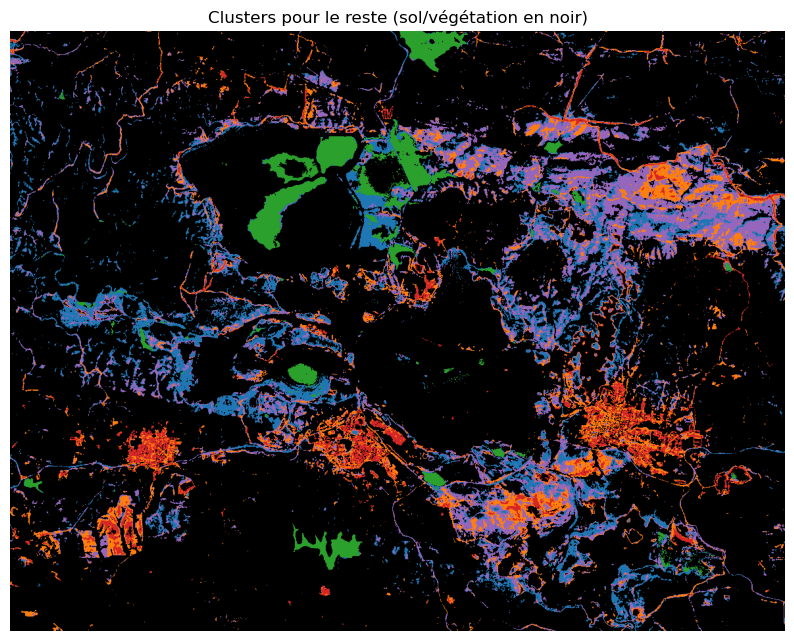

In [52]:
optimal_k = 5

# --- 6) K-Means final avec k optimal ---
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
labels = kmeans_final.fit_predict(X_scaled)

print("X_scaled shape :", X_scaled.shape)
print("labels shape   :", labels.shape)
print("labels uniques :", set(labels))

max_samples = 10000  # à ajuster si tu veux plus ou moins de précision
n_samples = X_scaled.shape[0]

if n_samples > max_samples:
    idx = np.random.choice(n_samples, max_samples, replace=False)
    X_sampled = X_scaled[idx]
    labels_sampled = labels[idx]
else:
    X_sampled = X_scaled
    labels_sampled = labels

sil_score = silhouette_score(X_sampled, labels_sampled)
ch_score  = calinski_harabasz_score(X_scaled, labels)

print(f"Silhouette (échantillon) pour k = {optimal_k} : {sil_score:.3f}")
print(f"Calinski-Harabasz pour k = {optimal_k} : {ch_score:.2f}")

# --- 7) Construction de la carte finale ---
cluster_map = np.zeros((m, n), dtype=int)
cluster_map[other_mask_2d] = labels + 1  # 0 = fond, clusters à partir de 1

# nombre de clusters sol
K = labels.max() + 1

# Création d'une colormap : noir pour 0, puis couleurs distinctes
cmap_colors = ["black"] + list(plt.cm.tab10.colors[:K])
cmap = colors.ListedColormap(cmap_colors)

plt.figure(figsize=(10, 10))
plt.imshow(cluster_map, cmap=cmap)
plt.title("Clusters pour le reste (sol/végétation en noir)")
plt.axis("off")
plt.show()

Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done
Done


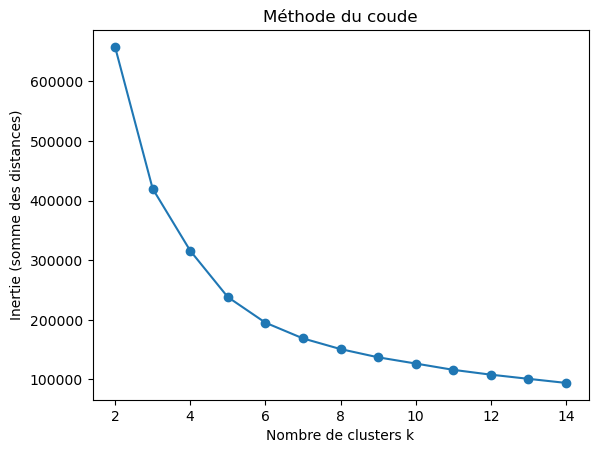

k optimal trouvé = 5


In [53]:
# Flatten mask

image_path = r'./SENTINEL2B_20240410-112055-466_L2A_T29SQB_C_V3-1_FRE_extrait_stack_gain_VNIR10.img'
raster_img = rio.open(image_path)
arr_img = reshape_as_image(raster_img.read())  # (m, n, l)
image = reshape_as_raster(arr_img)
l, m, n = image.shape

soil_mask_2d = (soil_only[:, :, 0] != 0)  # prendre la première bande uniquement
soil_mask_1d = soil_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = image.reshape(l, -1).T   
soil_pixels = pixels[soil_mask_1d]     

scaler = StandardScaler()
X_scaled = scaler.fit_transform(soil_pixels)

inertias = []

K_range = range(2, 15, 1)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=3, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    print("Done")

plt.plot(K_range, inertias, marker='o')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie (somme des distances)')
plt.title('Méthode du coude')
plt.show()

knee = KneeLocator(K_range, inertias, curve='convex', direction='decreasing')
optimal_k = knee.knee

print(f"k optimal trouvé = {optimal_k}")


5 classes pour le sol

(171907,)
(171907, 8)
       Cluster  Mean_std_all_bands
0    Cluster 1            0.224191
1    Cluster 2            0.284775
2    Cluster 3            0.534562
3    Cluster 4            0.210442
4    Cluster 5            0.348831
5    Cluster 6            0.216928
6    Cluster 7            0.255256
7    Cluster 8            0.393662
8    Cluster 9            0.273933
9   Cluster 10            0.197987
10  Cluster 11            0.196823
11  Cluster 12            0.172416
12  Cluster 13            0.863547
13  Cluster 14            0.331239
14  Cluster 15            0.196241
             Bande_1   Bande_2   Bande_3   Bande_4   Bande_5   Bande_6  \
Cluster_1   0.443857  0.350801  0.156360  0.055733  0.017298  0.017589   
Cluster_2  -1.251165 -1.362073 -1.341187 -1.326077 -1.352307 -1.362091   
Cluster_3   3.035956  3.078083  2.922277  2.716271  2.666831  2.696381   
Cluster_4  -0.786130 -0.746369 -0.634918 -0.533421 -0.511127 -0.523690   
Cluster_5   0.246625  0.749697  1.207722  1.3763

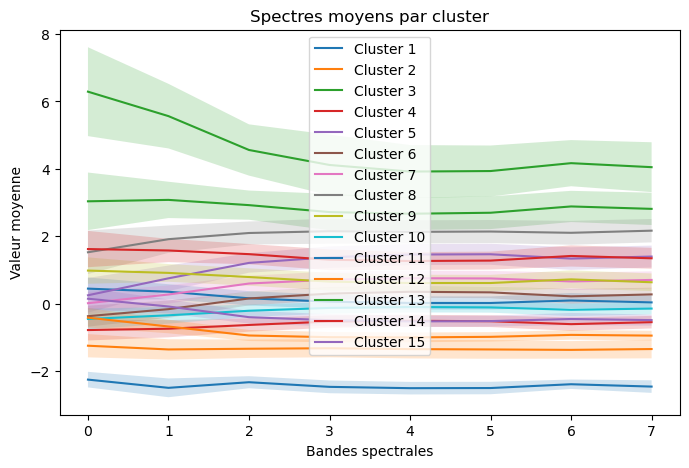

In [58]:
optimal_k = 15

# --- 6) K-Means final avec k optimal ---
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
labels = kmeans_final.fit_predict(X_scaled)
print(labels.shape)
print(soil_pixels.shape)

# Calcul des moyennes par cluster
mean_spectra = np.zeros((optimal_k, soil_pixels.shape[1]))
std_spectra = np.zeros((optimal_k, soil_pixels.shape[1]))
mean_std_per_cluster = np.zeros(optimal_k)

for k in range(optimal_k):
    cluster_pixels = X_scaled[labels == k]
    mean_spectra[k] = cluster_pixels.mean(axis=0)
    std_spectra[k]  = cluster_pixels.std(axis=0)
    mean_std_per_cluster[k] = std_spectra[k].mean() # moyenne de l'écart-type sur toutes les bandes

# Affichage sous forme de DataFrame
df = pd.DataFrame({
    'Cluster': [f'Cluster {i+1}' for i in range(optimal_k)],
    'Mean_std_all_bands': mean_std_per_cluster
})

# Option : afficher sous forme de tableau avec pandas
df_mean_spectra = pd.DataFrame(
    mean_spectra, 
    columns=[f'Bande_{i+1}' for i in range(soil_pixels.shape[1])]
)

print(df)
df_mean_spectra.index = [f'Cluster_{i+1}' for i in range(optimal_k)]

print(df_mean_spectra)

plt.figure(figsize=(8,5))
bands = np.arange(l)

for k in range(optimal_k):
    plt.plot(mean_spectra[k], label=f'Cluster {k+1}')
    plt.fill_between(
        bands,
        mean_spectra[k] - std_spectra[k],
        mean_spectra[k] + std_spectra[k],
        alpha=0.2
    )
plt.xlabel('Bandes spectrales')
plt.ylabel('Valeur moyenne')
plt.title('Spectres moyens par cluster')
plt.legend()
plt.show()

Silhouette (échantillon) pour k = 15 : 0.284
Calinski-Harabasz pour k = 15 : 175565.56


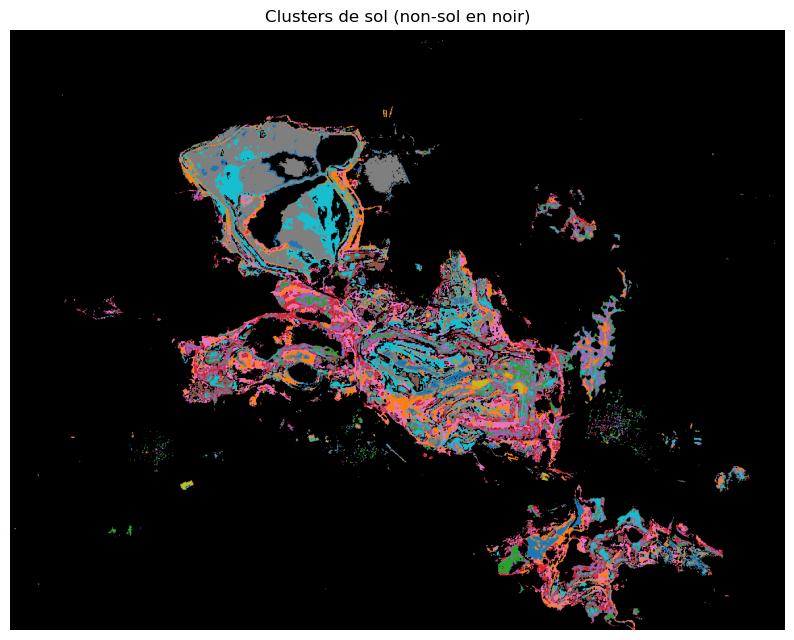

In [59]:
import matplotlib.colors as colors

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels = kmeans.fit_predict(X_scaled)

max_samples = 10000  # à ajuster si tu veux plus ou moins de précision
n_samples = X_scaled.shape[0]

if n_samples > max_samples:
    idx = np.random.choice(n_samples, max_samples, replace=False)
    X_sampled = X_scaled[idx]
    labels_sampled = labels[idx]
else:
    X_sampled = X_scaled
    labels_sampled = labels

sil_score = silhouette_score(X_sampled, labels_sampled)
ch_score  = calinski_harabasz_score(X_scaled, labels)

print(f"Silhouette (échantillon) pour k = {optimal_k} : {sil_score:.3f}")
print(f"Calinski-Harabasz pour k = {optimal_k} : {ch_score:.2f}")



# Carte vide
cluster_map = np.zeros((m, n), dtype=int) 

# On "injecte" les labels K-means dans la carte finale
cluster_map[soil_mask_2d] = labels + 1

# nombre de clusters végétation
K = labels.max() + 1

# Création d'une colormap : noir pour 0, puis couleurs distinctes
cmap_colors = ["black"] + list(plt.cm.tab10.colors[:K])
cmap = colors.ListedColormap(cmap_colors)

plt.figure(figsize=(10, 10))
plt.imshow(cluster_map, cmap=cmap)
plt.title("Clusters de sol (non-sol en noir)")
plt.axis("off")
plt.show()

Cette méthode (séparation + inertie) conseille donc 15 clusters #(entre 15 et 20).